# Residual Load Duration Curve and Tail Risk

This notebook focuses on the **duration curve / tail risk** part of the challenge.

Residual load is defined as:

`residual load = demand - scaled solar - scaled wind`

For this topic, the relevant tail is the **upper/right tail**: hours where residual load is unusually high. These are the hours where demand remains high after scaled wind and solar generation, so the system needs more dispatchable generation, storage, or imports.

We compare three renewable scaling scenarios: `(solar, wind) = (0.01, 0.05)`, `(0.13, 0.17)`, and `(0.22, 0.28)`.

The lower/left tail is a different risk: renewable surplus, curtailment, or negative-price risk.

In [55]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("default")
plt.rcParams["figure.figsize"] = (11, 5)

### 1. Load Data and Build European Residual Load

We aggregate by `Time`, summing all buses into one European system-level time series.

In [56]:
dataset = pd.read_parquet(
    "renewables-dataset.parquet",
    columns=["Time", "ID", "country", "demand_MWh", "solar_MWh", "wind_MWh"],
)

dataset["Time"] = pd.to_datetime(dataset["Time"])

europe = (
    dataset.groupby("Time", as_index=False)
    .agg(
        demand_MWh=("demand_MWh", "sum"),
        solar_MWh=("solar_MWh", "sum"),
        wind_MWh=("wind_MWh", "sum"),
    )
    .sort_values("Time")
)

scenarios = {
    "solar=0.01, wind=0.05": {"solar_scale": 0.01, "wind_scale": 0.05, "key": "s001_w005"},
    "solar=0.13, wind=0.17": {"solar_scale": 0.13, "wind_scale": 0.17, "key": "s013_w017"},
    "solar=0.22, wind=0.28": {"solar_scale": 0.22, "wind_scale": 0.28, "key": "s022_w028"},
}

for scenario, values in scenarios.items():
    key = values["key"]
    europe[f"solar_scaled_{key}_MWh"] = values["solar_scale"] * europe["solar_MWh"]
    europe[f"wind_scaled_{key}_MWh"] = values["wind_scale"] * europe["wind_MWh"]
    europe[f"renewable_{key}_MWh"] = (
        europe[f"solar_scaled_{key}_MWh"] + europe[f"wind_scaled_{key}_MWh"]
    )
    europe[f"residual_{key}_MWh"] = europe["demand_MWh"] - europe[f"renewable_{key}_MWh"]

# Keep one default residual column for later single-scenario cells.
default_scenario = "solar=0.13, wind=0.17"
default_key = scenarios[default_scenario]["key"]
europe["renewable_MWh"] = europe[f"renewable_{default_key}_MWh"]
europe["residual_MWh"] = europe[f"residual_{default_key}_MWh"]

europe.head()


,Time,demand_MWh,solar_MWh,wind_MWh,solar_scaled_s001_w005_MWh,wind_scaled_s001_w005_MWh,renewable_s001_w005_MWh,residual_s001_w005_MWh,solar_scaled_s013_w017_MWh,wind_scaled_s013_w017_MWh,renewable_s013_w017_MWh,residual_s013_w017_MWh,solar_scaled_s022_w028_MWh,wind_scaled_s022_w028_MWh,renewable_s022_w028_MWh,residual_s022_w028_MWh,renewable_MWh,residual_MWh
0,2012-01-01 00:00:00+00:00,243569.8974,0.0,363743.961518,0.0,18187.198076,18187.198076,225382.699324,0.0,61836.473458,61836.473458,181733.423942,0.0,101848.309225,101848.309225,141721.588175,61836.473458,181733.423942
1,2012-01-01 01:00:00+00:00,234513.1048,0.0,383164.065917,0.0,19158.203296,19158.203296,215354.901504,0.0,65137.891206,65137.891206,169375.213594,0.0,107285.938457,107285.938457,127227.166343,65137.891206,169375.213594
2,2012-01-01 02:00:00+00:00,221948.7645,0.0,398552.680613,0.0,19927.634031,19927.634031,202021.130469,0.0,67753.955704,67753.955704,154194.808796,0.0,111594.750572,111594.750572,110354.013928,67753.955704,154194.808796
3,2012-01-01 03:00:00+00:00,210827.3966,0.0,410849.281467,0.0,20542.464073,20542.464073,190284.932527,0.0,69844.377849,69844.377849,140983.018751,0.0,115037.798811,115037.798811,95789.597789,69844.377849,140983.018751
4,2012-01-01 04:00:00+00:00,203918.9157,0.0,416633.812564,0.0,20831.690628,20831.690628,183087.225072,0.0,70827.748136,70827.748136,133091.167564,0.0,116657.467518,116657.467518,87261.448182,70827.748136,133091.167564


### 2. Tail Thresholds by Scenario

For each scaling scenario, we use p90, p95, and p99 of residual load to define increasingly extreme high-residual-load hours.

In [57]:
tail_rows = []

for scenario, values in scenarios.items():
    residual_col = f"residual_{values['key']}_MWh"
    quantiles = europe[residual_col].quantile([0.50, 0.90, 0.95, 0.99])
    tail_rows.append(
        {
            "scenario": scenario,
            "solar_scale": values["solar_scale"],
            "wind_scale": values["wind_scale"],
            "p50_GWh": quantiles.loc[0.50] / 1000,
            "p90_GWh": quantiles.loc[0.90] / 1000,
            "p95_GWh": quantiles.loc[0.95] / 1000,
            "p99_GWh": quantiles.loc[0.99] / 1000,
            "max_GWh": europe[residual_col].max() / 1000,
        }
    )

tail_summary = pd.DataFrame(tail_rows)
tail_summary


,scenario,solar_scale,wind_scale,p50_GWh,p90_GWh,p95_GWh,p99_GWh,max_GWh
0,"solar=0.01, wind=0.05",0.01,0.05,262.422671,321.646932,338.071538,361.446326,409.855504
1,"solar=0.13, wind=0.17",0.13,0.17,192.798642,262.119395,284.507706,322.225748,383.889551
2,"solar=0.22, wind=0.28",0.22,0.28,149.162416,232.286550,254.376855,297.791721,360.087427


### 3. Residual Load Duration Curve by Scenario

A duration curve sorts hourly residual load from highest to lowest. The left side of the curve shows the most stressful hours. Comparing scenarios shows how renewable scaling changes the upper tail.

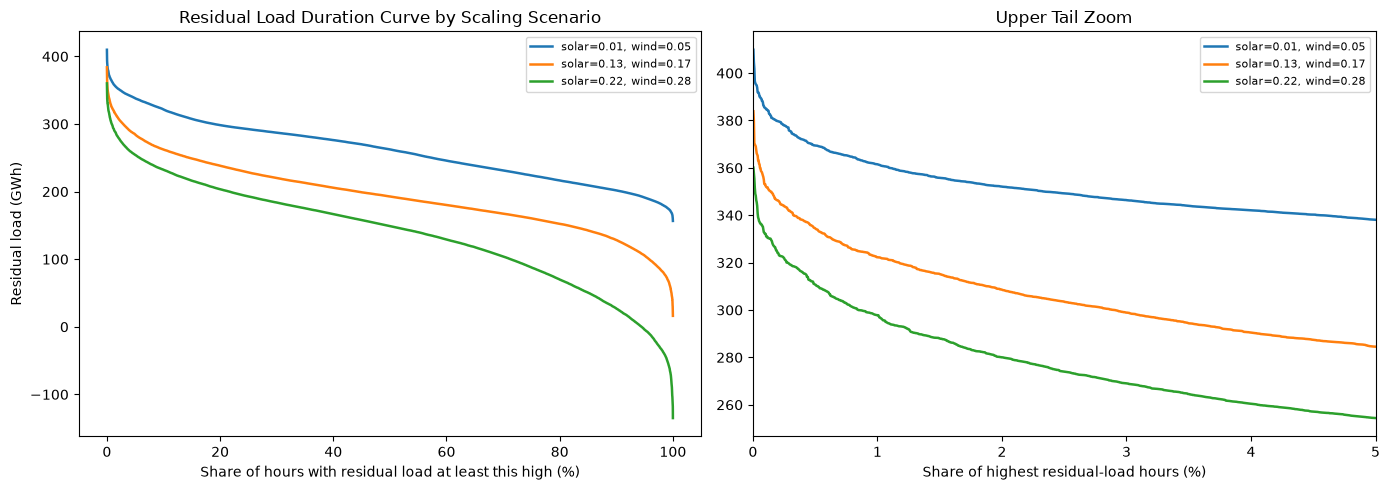

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {
    "solar=0.01, wind=0.05": "tab:blue",
    "solar=0.13, wind=0.17": "tab:orange",
    "solar=0.22, wind=0.28": "tab:green",
}
for scenario, values in scenarios.items():
    residual_sorted = europe[f"residual_{values['key']}_MWh"].sort_values(ascending=False).reset_index(drop=True)
    exceedance_pct = (np.arange(1, len(residual_sorted) + 1) / len(residual_sorted)) * 100
    axes[0].plot(exceedance_pct, residual_sorted / 1000, linewidth=1.8, label=scenario, color=colors[scenario])
    axes[1].plot(exceedance_pct, residual_sorted / 1000, linewidth=1.8, label=scenario, color=colors[scenario])
axes[0].set_title("Residual Load Duration Curve by Scaling Scenario")
axes[0].set_xlabel("Share of hours with residual load at least this high (%)")
axes[0].set_ylabel("Residual load (GWh)")
axes[0].legend(fontsize=8)
axes[1].set_xlim(0, 5)
upper_tail_min = tail_summary["p95_GWh"].min()
upper_tail_max = tail_summary["max_GWh"].max()
padding = 0.05 * (upper_tail_max - upper_tail_min)
axes[1].set_ylim(upper_tail_min - padding, upper_tail_max + padding)
axes[1].set_title("Upper Tail Zoom")
axes[1].set_xlabel("Share of highest residual-load hours (%)")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()


### 4. Upper-Tail Threshold Comparison

This plot compares p95 and p99 residual-load thresholds across the renewable scaling scenarios.

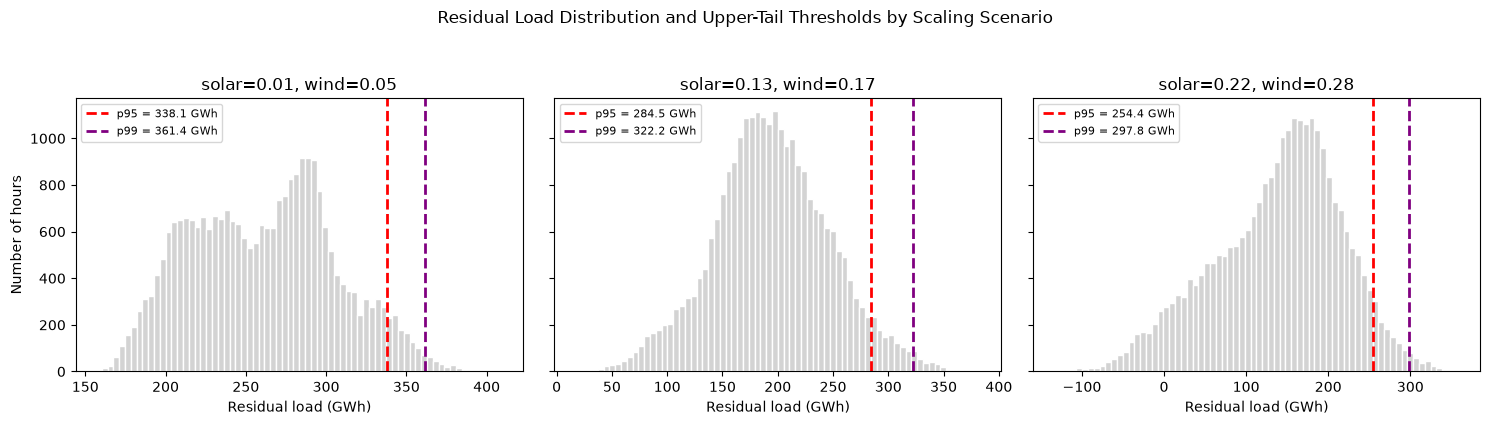

,scenario,p95_GWh,p99_GWh,max_GWh
0,"solar=0.01, wind=0.05",338.071538,361.446326,409.855504
1,"solar=0.13, wind=0.17",284.507706,322.225748,383.889551
2,"solar=0.22, wind=0.28",254.376855,297.791721,360.087427


In [59]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, (scenario, values) in zip(axes, scenarios.items()):
    residual_col = f"residual_{values['key']}_MWh"
    residual_gwh = europe[residual_col] / 1000
    q95 = tail_summary.loc[tail_summary["scenario"] == scenario, "p95_GWh"].iloc[0]
    q99 = tail_summary.loc[tail_summary["scenario"] == scenario, "p99_GWh"].iloc[0]

    ax.hist(residual_gwh, bins=70, color="lightgray", edgecolor="white")
    ax.axvline(q95, color="red", linestyle="--", linewidth=2, label=f"p95 = {q95:.1f} GWh")
    ax.axvline(q99, color="purple", linestyle="--", linewidth=2, label=f"p99 = {q99:.1f} GWh")
    ax.set_title(scenario)
    ax.set_xlabel("Residual load (GWh)")
    ax.legend(fontsize=8)

axes[0].set_ylabel("Number of hours")
fig.suptitle("Residual Load Distribution and Upper-Tail Thresholds by Scaling Scenario", y=1.05)
plt.tight_layout()
plt.show()

tail_summary[["scenario", "p95_GWh", "p99_GWh", "max_GWh"]]


### 5. Tail Events Over Time

A p95 tail event is an hour where residual load is above the historical 95th percentile.

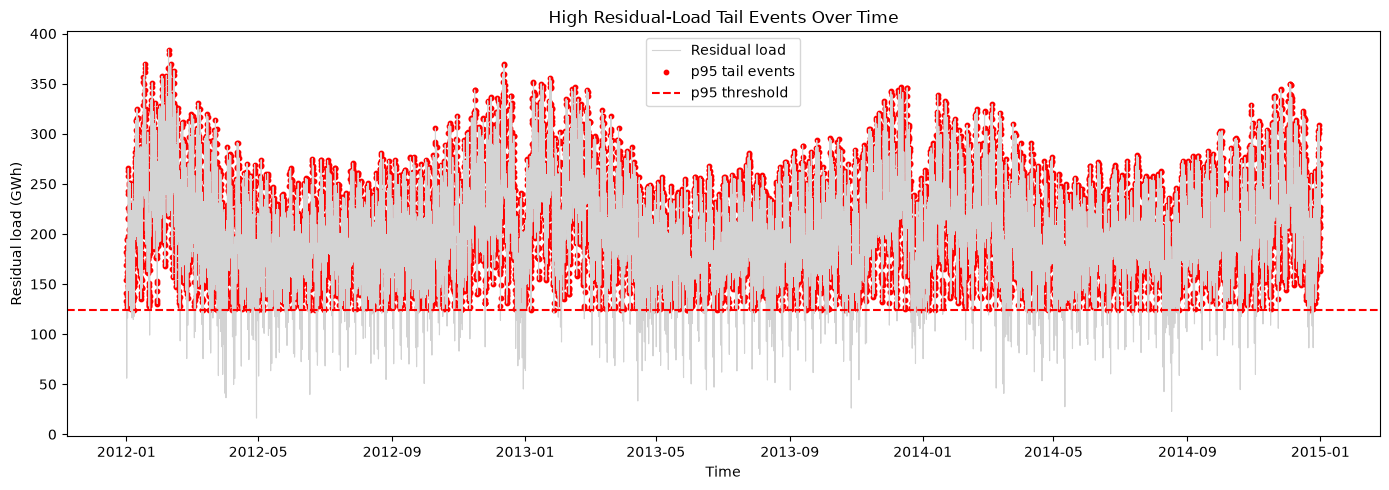

In [60]:
europe["tail_p95"] = europe["residual_MWh"] >= p95
europe["tail_p99"] = europe["residual_MWh"] >= p99

plt.figure(figsize=(14, 5))
plt.plot(europe["Time"], europe["residual_MWh"] / 1000, color="lightgray", linewidth=0.8, label="Residual load")
plt.scatter(
    europe.loc[europe["tail_p95"], "Time"],
    europe.loc[europe["tail_p95"], "residual_MWh"] / 1000,
    s=10,
    color="red",
    label="p95 tail events",
)
plt.axhline(p95 / 1000, color="red", linestyle="--", linewidth=1.5, label="p95 threshold")
plt.xlabel("Time")
plt.ylabel("Residual load (GWh)")
plt.title("High Residual-Load Tail Events Over Time")
plt.legend()
plt.tight_layout()
plt.show()

### 6. Monthly Tail Event Frequency

This shows whether high-residual-load stress is seasonal.

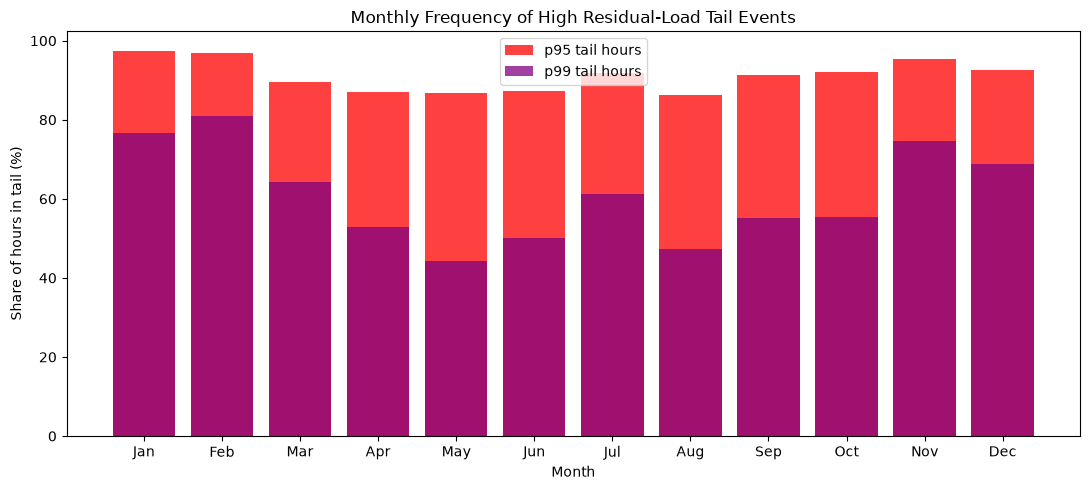

,month,hours,p95_tail_hours,p99_tail_hours,mean_residual_MWh,p95_tail_share_pct,p99_tail_share_pct
0,1,2232,2176,1709,221824.182922,97.491039,76.568100
1,2,2040,1978,1651,227075.510396,96.960784,80.931373
2,3,2232,1998,1436,196054.540597,89.516129,64.336918
3,4,2160,1877,1144,179796.271255,86.898148,52.962963
4,5,2232,1937,986,171718.667590,86.783154,44.175627
5,6,2160,1887,1081,176356.416589,87.361111,50.046296
6,7,2232,2051,1367,188162.685794,91.890681,61.245520
7,8,2232,1924,1058,175027.698461,86.200717,47.401434
8,9,2160,1972,1189,185363.537635,91.296296,55.046296
9,10,2232,2055,1235,188338.308359,92.069892,55.331541


In [61]:
europe["month"] = europe["Time"].dt.month
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

monthly_tail = (
    europe.groupby("month")
    .agg(
        hours=("Time", "count"),
        p95_tail_hours=("tail_p95", "sum"),
        p99_tail_hours=("tail_p99", "sum"),
        mean_residual_MWh=("residual_MWh", "mean"),
    )
    .reset_index()
)
monthly_tail["p95_tail_share_pct"] = 100 * monthly_tail["p95_tail_hours"] / monthly_tail["hours"]
monthly_tail["p99_tail_share_pct"] = 100 * monthly_tail["p99_tail_hours"] / monthly_tail["hours"]

plt.figure(figsize=(11, 5))
plt.bar(monthly_tail["month"], monthly_tail["p95_tail_share_pct"], color="red", alpha=0.75, label="p95 tail hours")
plt.bar(monthly_tail["month"], monthly_tail["p99_tail_share_pct"], color="purple", alpha=0.75, label="p99 tail hours")
plt.xticks(range(1, 13), month_labels)
plt.xlabel("Month")
plt.ylabel("Share of hours in tail (%)")
plt.title("Monthly Frequency of High Residual-Load Tail Events")
plt.legend()
plt.tight_layout()
plt.show()

monthly_tail

### 7. What Drives the Upper Tail?

Compare average demand, solar, and wind during normal hours versus p95 tail hours.

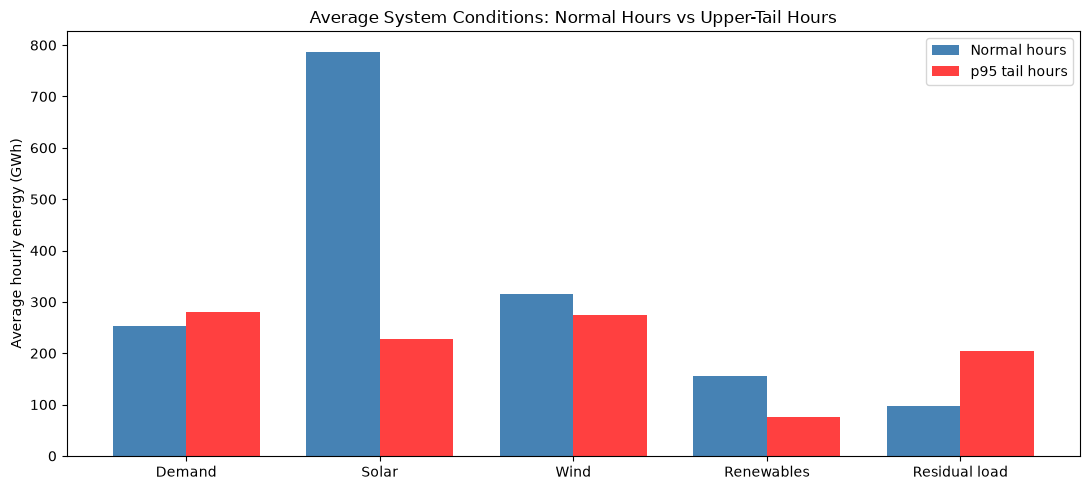

,component,normal_hours_GWh,p95_tail_hours_GWh
0,Demand,253.303614,279.859722
1,Solar,787.523966,228.001982
2,Wind,315.740194,273.820159
3,Renewables,156.053949,76.189685
4,Residual load,97.249665,203.670037


In [62]:
normal = europe.loc[~europe["tail_p95"]]
tail = europe.loc[europe["tail_p95"]]

component_summary = pd.DataFrame(
    {
        "component": ["Demand", "Solar", "Wind", "Renewables", "Residual load"],
        "normal_hours_GWh": [
            normal["demand_MWh"].mean() / 1000,
            normal["solar_MWh"].mean() / 1000,
            normal["wind_MWh"].mean() / 1000,
            normal["renewable_MWh"].mean() / 1000,
            normal["residual_MWh"].mean() / 1000,
        ],
        "p95_tail_hours_GWh": [
            tail["demand_MWh"].mean() / 1000,
            tail["solar_MWh"].mean() / 1000,
            tail["wind_MWh"].mean() / 1000,
            tail["renewable_MWh"].mean() / 1000,
            tail["residual_MWh"].mean() / 1000,
        ],
    }
)

x = np.arange(len(component_summary))
width = 0.38

plt.figure(figsize=(11, 5))
plt.bar(x - width / 2, component_summary["normal_hours_GWh"], width, label="Normal hours", color="steelblue")
plt.bar(x + width / 2, component_summary["p95_tail_hours_GWh"], width, label="p95 tail hours", color="red", alpha=0.75)
plt.xticks(x, component_summary["component"])
plt.ylabel("Average hourly energy (GWh)")
plt.title("Average System Conditions: Normal Hours vs Upper-Tail Hours")
plt.legend()
plt.tight_layout()
plt.show()

component_summary

### Key Interpretation

- The duration curve focuses on the highest residual-load hours, where system stress is greatest.
- The upper tail is the relevant tail because high residual load means demand remains high after scaled wind and solar generation.
- p95 and p99 thresholds summarize rare but important hours where backup generation, imports, storage, or flexibility are most needed.
- Low or negative residual load is a separate problem: curtailment / negative risk.